# QS-Net (PyTorch Version)
## Version 2.2: 2,000 Training Data Points (Class Balanced) | Batch Size 64 | 15 Epochs | Added Logging

This notebook implements the three QS-Net algorithms, incorporating 3 different algorithms:

1. **Algorithm 1 (MAQT)** shapes Hilbert-space geometry with cross-entropy + intra/inter prototype losses.
2. **Algorithm 2 (CQ-ZDR)** sets a conformal zero-day threshold from known-class calibration data.
3. **Algorithm 3 (Inference)** classifies with a certified radius or flags `ZERO_DAY`.

## Setup

In [1]:
import pennylane as qp
from pennylane import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import json
from pathlib import Path

In [2]:
from scripts.constants import DEFAULT_CF, DEFAULT_NOISE_RATE, ZERO_DAY
from scripts.data import (
    balanced_sample,
    class_balance_table,
    load_split,
    plot_class_balance_pie,
    stratified_head,
)
from scripts.circuit import build_forward_circuit, create_quantum_device, initialize_weights
from scripts.conformal import calibrate_threshold
from scripts.prototypes import PrototypeBank, compute_prototypes
from scripts.loss import maqt_loss, gradient_variance
from scripts.logging import write_history_log
from scripts.inference import estimate_lipschitz, predict_batch
from scripts.utils import expectations_to_tensor, get_torch_device, to_np_x, to_torch_x

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


## Load Dataset: TON IoT

In [4]:
df = pd.read_parquet("data/TON_IoT/quantum/q8_train.parquet")
df

,dst_pkts,protocol,src_pkts,dst_bytes,n_bytes_total,src_bytes,conn_state,duration,label_multiclass,label_binary,label_family
0,0.529836,3.141593,0.556692,1.088846,0.957560,0.758171,3.141593,0.005108,password,1.0,bruteforce_password
1,0.575419,3.141593,0.556692,1.082288,0.987983,0.828671,3.141593,0.017505,injection,1.0,web_injection
2,0.780388,3.141593,0.556692,1.344399,1.152061,0.873394,3.141593,0.535346,ddos,1.0,ddos
3,0.204968,0.836286,0.215358,0.568380,0.594294,0.591666,3.141593,0.001233,password,1.0,bruteforce_password
4,0.529836,3.141593,0.556692,0.901747,0.852190,0.750624,3.141593,0.000617,normal,0.0,benign
...,...,...,...,...,...,...,...,...,...,...,...
60303,0.000000,0.836286,0.430716,0.000000,0.360470,0.747692,3.141593,0.254447,NaN,NaN,NaN
60304,0.614905,3.141593,0.556692,1.165812,1.040995,0.844430,3.141593,0.023131,NaN,NaN,NaN
60305,0.900286,3.141593,1.066925,1.201364,1.140813,1.011379,3.141593,1.428035,NaN,NaN,NaN
60306,0.000000,3.141593,1.490032,0.000000,0.000000,0.000000,3.141593,0.069285,NaN,NaN,NaN


In [5]:
print(df["label_multiclass"].unique())
print()
print(df["label_family"].unique())

<ArrowStringArray>
[ 'password', 'injection',      'ddos',    'normal',       'xss',  'scanning',
  'backdoor',      'mitm',       'dos',         nan]
Length: 10, dtype: str

<ArrowStringArray>
[        'bruteforce_password',               'web_injection',
                        'ddos',                      'benign',
                       'recon', 'backdoor_malware_ransomware',
               'spoofing_mitm',                         'dos',
                           nan]
Length: 9, dtype: str


In [6]:
# check rows if NaN dropped in the label_multiclass column
df[df["label_multiclass"].notna()].copy()

,dst_pkts,protocol,src_pkts,dst_bytes,n_bytes_total,src_bytes,conn_state,duration,label_multiclass,label_binary,label_family
0,0.529836,3.141593,0.556692,1.088846,0.957560,0.758171,3.141593,0.005108,password,1.0,bruteforce_password
1,0.575419,3.141593,0.556692,1.082288,0.987983,0.828671,3.141593,0.017505,injection,1.0,web_injection
2,0.780388,3.141593,0.556692,1.344399,1.152061,0.873394,3.141593,0.535346,ddos,1.0,ddos
3,0.204968,0.836286,0.215358,0.568380,0.594294,0.591666,3.141593,0.001233,password,1.0,bruteforce_password
4,0.529836,3.141593,0.556692,0.901747,0.852190,0.750624,3.141593,0.000617,normal,0.0,benign
...,...,...,...,...,...,...,...,...,...,...,...
41490,0.529836,3.141593,0.604586,1.112493,1.097880,1.022555,3.141593,0.000815,normal,0.0,benign
41491,0.529836,3.141593,0.646074,1.092155,0.994987,0.832071,3.141593,0.232142,normal,0.0,benign
41492,0.885859,3.141593,0.987408,0.988759,1.053146,1.069316,3.141593,1.413128,injection,1.0,web_injection
41493,0.575419,3.141593,0.556692,1.165812,1.037165,0.836487,3.141593,0.038636,normal,0.0,benign


In [7]:
# get labels
class_names = sorted(df["label_multiclass"].dropna().unique())
class_names

['backdoor',
 'ddos',
 'dos',
 'injection',
 'mitm',
 'normal',
 'password',
 'scanning',
 'xss']

In [8]:
# load all data
X_train_full, y_train_full = load_split("train", class_names)
X_cal_full, y_cal_full = load_split("calibration", class_names)
X_test_full, y_test_full = load_split("test", class_names)
X_val_full, y_val_full = load_split("val", class_names)

In [9]:
# check shape
[X_train_full.shape, y_train_full.shape], [X_cal_full.shape, y_cal_full.shape], [X_test_full.shape, y_test_full.shape], [X_val_full.shape, y_val_full.shape]

([(41495, 8), (41495,)],
 [(779, 8), (779,)],
 [(785, 8), (785,)],
 [(784, 8), (784,)])

## EDA (Before Class-Balancing)

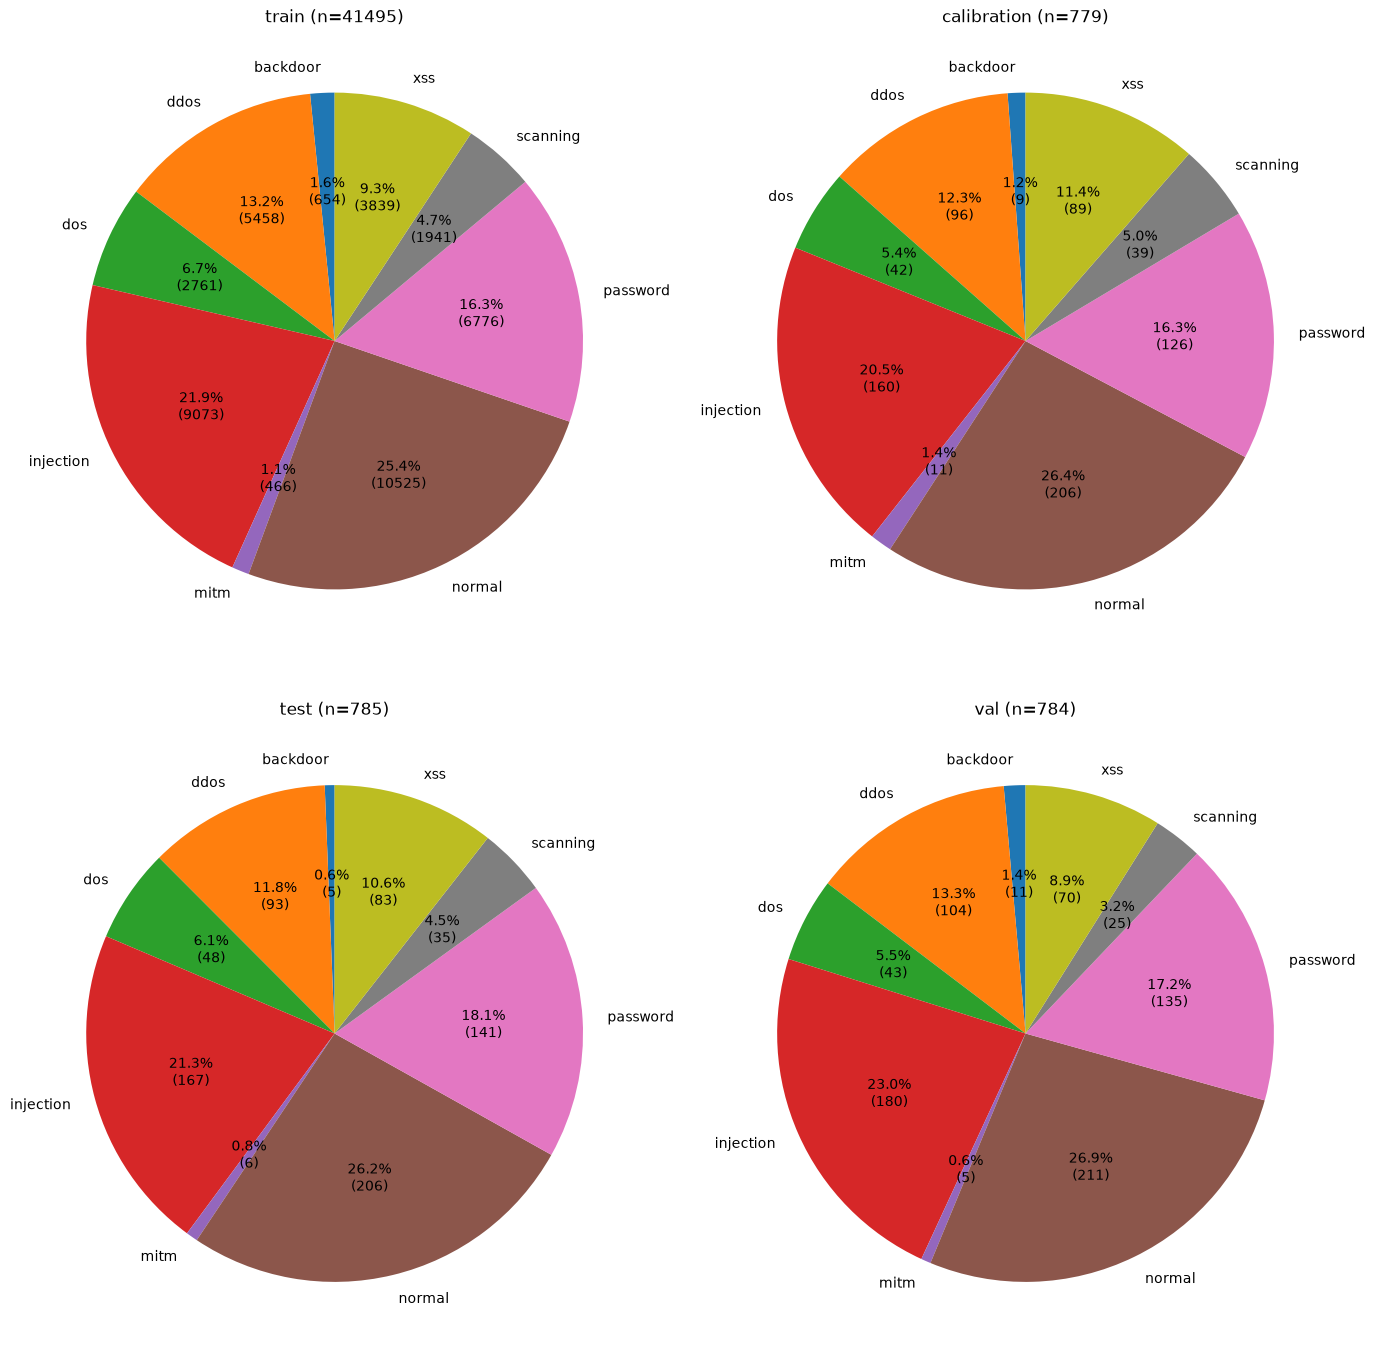

In [10]:
# pie chart
splits = {
    "train": y_train_full,
    "calibration": y_cal_full,
    "test": y_test_full,
    "val": y_val_full,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, (name, y) in zip(axes.ravel(), splits.items()):
    plot_class_balance_pie(y, class_names, title=f"{name} (n={len(to_np_x(y))})", ax=ax)

plt.tight_layout()
plt.show()

## Class Balancing

In [11]:
# use the smallest class size as the target count for undersampling
n_per_class = 466

# balance class on full data
X_train_balanced, y_train_balanced = balanced_sample(X_train_full, y_train_full, n_per_class=n_per_class, seed=42)
X_train_balanced.shape, y_train_balanced.shape

((4194, 8), (4194,))

In [12]:
# take subset
X_train, y_train = stratified_head(X_train_balanced, y_train_balanced, 2000, seed=42)

X_cal = X_cal_full[:]
y_cal = y_cal_full[:]

X_test = X_test_full[:]
y_test = y_test_full[:]

X_val = X_val_full[:]
y_val = y_val_full[:]

In [13]:
# check shape
[X_train.shape, y_train.shape], [X_cal.shape, y_cal.shape], [X_test.shape, y_test.shape], [X_val.shape, y_val.shape]

([(2000, 8), (2000,)],
 [(779, 8), (779,)],
 [(785, 8), (785,)],
 [(784, 8), (784,)])

## EDA (After Class-Balancing)

In [14]:
num_classes = len(class_names)
num_qubits = X_train.shape[1]

print(f"classes: {class_names}")
print(f"number of classes: {num_classes}")
print(f"number of qubits: {num_qubits}")

classes: ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'scanning', 'xss']
number of classes: 9
number of qubits: 8


In [15]:
# initialize devices
dev = qp.device("default.mixed", wires=num_qubits)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [16]:
# convert data type
X_train = to_torch_x(X_train)
y_train = to_torch_x(y_train).long()

In [17]:
# check shape
[X_train.shape, y_train.shape], [X_cal.shape, y_cal.shape], [X_test.shape, y_test.shape], [X_val.shape, y_val.shape]

([torch.Size([2000, 8]), torch.Size([2000])],
 [(779, 8), (779,)],
 [(785, 8), (785,)],
 [(784, 8), (784,)])

In [18]:
# table
splits = {
    "train": y_train,
    "calibration": y_cal,
    "test": y_test,
    "val": y_val,
}

for name, y in splits.items():
    table = class_balance_table(y, class_names)
    print(f"{name} (n={len(to_np_x(y))})")
    display(table)

train (n=2000)


,class,count,pct
0,backdoor,222,11.10
1,ddos,222,11.10
2,dos,222,11.10
3,injection,223,11.15
4,mitm,222,11.10
5,normal,222,11.10
6,password,223,11.15
7,scanning,222,11.10
8,xss,222,11.10


calibration (n=779)


,class,count,pct
0,backdoor,9,1.155327
1,ddos,96,12.323492
2,dos,42,5.391528
3,injection,160,20.539153
4,mitm,11,1.412067
5,normal,206,26.444159
6,password,127,16.302953
7,scanning,39,5.006418
8,xss,89,11.424904


test (n=785)


,class,count,pct
0,backdoor,5,0.636943
1,ddos,93,11.847134
2,dos,48,6.114650
3,injection,167,21.273885
4,mitm,6,0.764331
5,normal,206,26.242038
6,password,142,18.089172
7,scanning,35,4.458599
8,xss,83,10.573248


val (n=784)


,class,count,pct
0,backdoor,11,1.403061
1,ddos,104,13.265306
2,dos,43,5.484694
3,injection,180,22.959184
4,mitm,5,0.637755
5,normal,211,26.913265
6,password,135,17.219388
7,scanning,25,3.188776
8,xss,70,8.928571


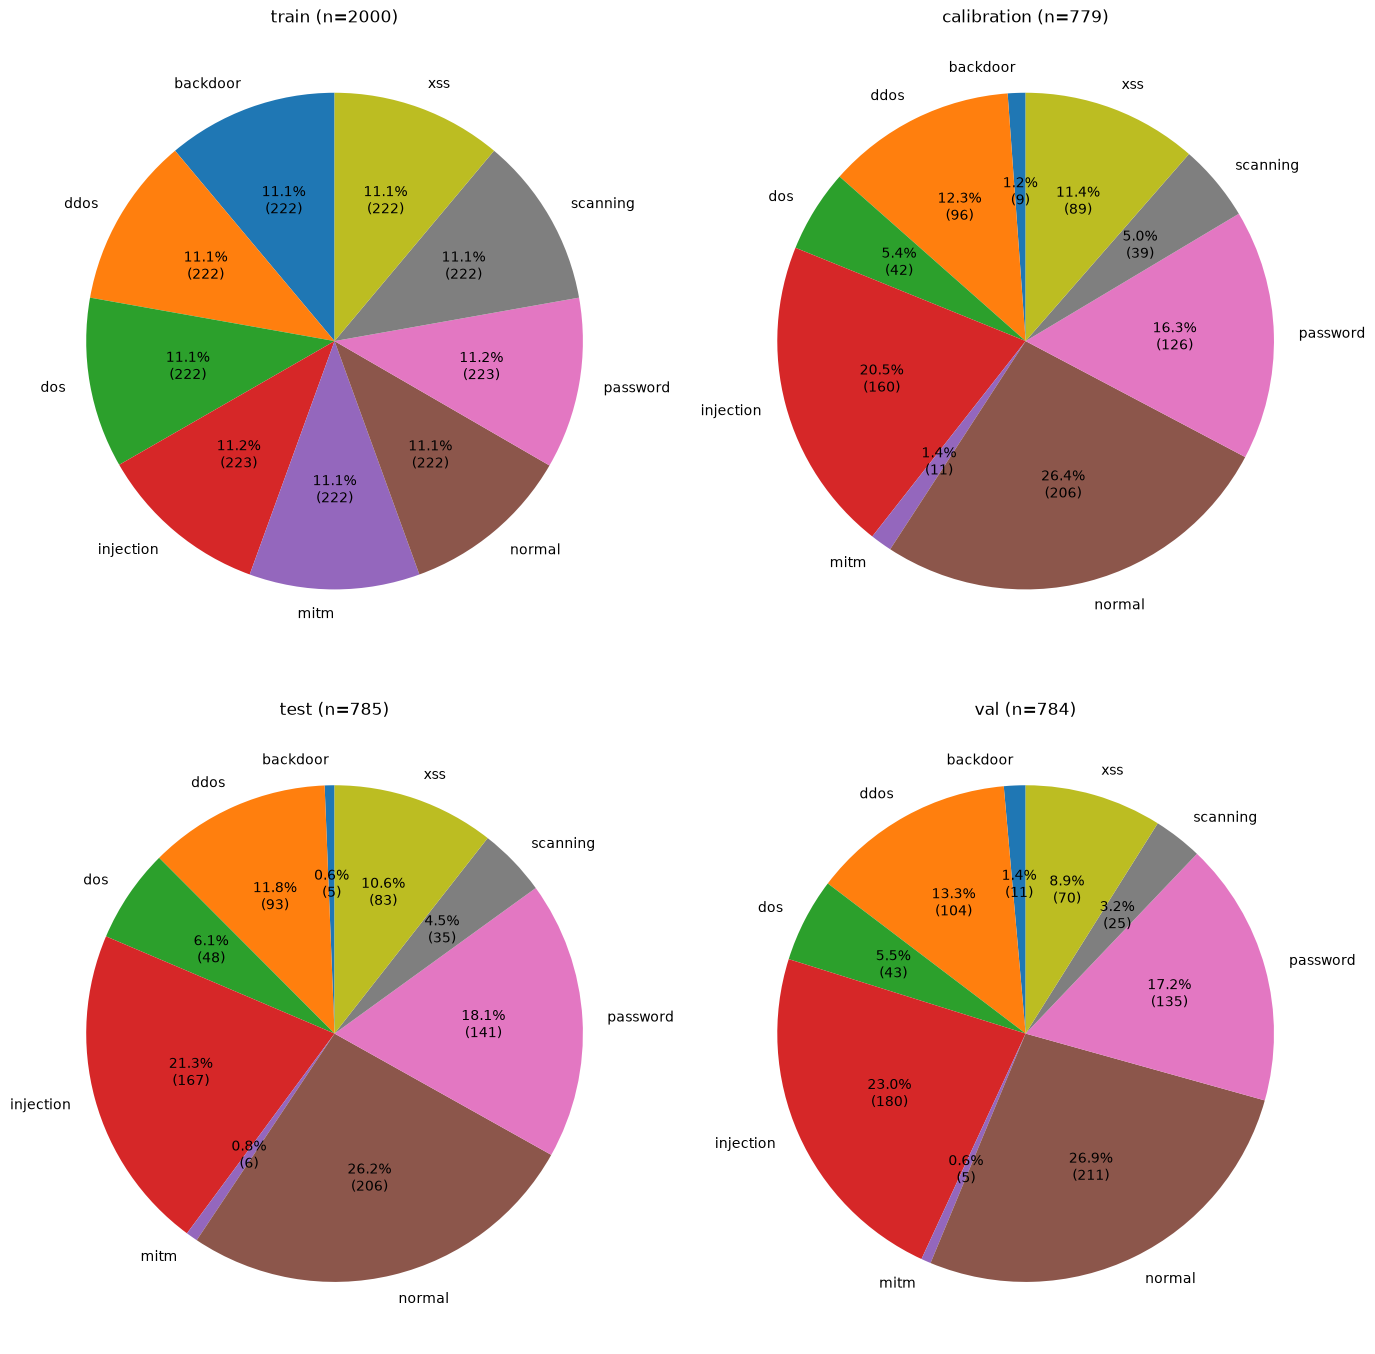

In [19]:
# pie chart
splits = {
    "train": y_train,
    "calibration": y_cal,
    "test": y_test,
    "val": y_val,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, (name, y) in zip(axes.ravel(), splits.items()):
    plot_class_balance_pie(y, class_names, title=f"{name} (n={len(to_np_x(y))})", ax=ax)

plt.tight_layout()
plt.show()

## Quantum Circuit: Angle Encoding, Data Reuploading, and Adding Noise

$x\xrightarrow[\text{encode}]{\phi(x)}\ket{\psi(x)}\xrightarrow[\text{variational}]{U(\theta)}\ket{\Phi(x)}\xrightarrow{\Lambda_p}\rho(x)$
- $x$: classical data
- $\phi(x)$: `qp.AngleEmbedding()`
- $\ket{\psi(x)}$: quantum state after encoding
- $U(\theta)$: `qp.StronglyEntanglingLayers()`
- $\ket{\Phi(x)}$: quantum state after variational transform
- $\rho(x)=\Lambda_p(\ket{\Phi(x)}\bra{\Phi(x)})$: standard depolarization channel to model NISQ noise

In [20]:
num_layers = 2                  # reupload same classical data
noise_rate = DEFAULT_NOISE_RATE
device = get_torch_device()

In [21]:
# initialize device
dev = create_quantum_device(num_qubits)

# define circuit
forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)

# initialize weights
theta = initialize_weights(num_layers, num_qubits, device)

# define classifier head
classifier_head = nn.Linear(num_qubits, num_classes).to(device)

In [22]:
# initialize weights
theta = initialize_weights(num_layers, num_qubits, device)
theta.shape

torch.Size([2, 8, 3])

In [23]:
# DEBUG
theta

Parameter containing:
tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]], device='cuda:0', requires_grad=True)

## Training

Minimizing:
- $L_{CE}$ adjusts $\theta$ for better class predictions.
- $L_{intra}$ pulls each sample toward its class prototype
- $L_{inter}$ pushs different-class prototypes apart (maximize trace distance)

In [24]:
lambda1 = 0.5
lambda2 = 0.3
epochs = 15
batch_size = 64
lr = 0.01
barren_plateau_var = 1e-6
COMPUTE_GRAD_VAR = True

In [25]:
# define loss function
ce_loss_fn = nn.CrossEntropyLoss()

# define optimizer
optimizer = torch.optim.Adam(list([theta]) + list(classifier_head.parameters()), lr=lr)

# define prototype bank
prototype_bank = PrototypeBank(range(num_classes))

In [26]:
history = {
    "loss": [], "l_ce": [], "l_intra": [], "l_inter": [],
    "grad_var": [], "barren_plateau": [],
}

num_batches = (len(X_train) + batch_size - 1) // batch_size
print(f"training: {len(X_train)} samples, {num_batches} batches/epoch, {epochs} epochs")

for epoch in range(epochs):
    prototype_bank.reset()
    perm = torch.randperm(len(X_train), device=device)

    epoch_grad_vars = []
    epoch_loss, epoch_ce, epoch_intra, epoch_inter = [], [], [], []

    for batch_idx, start in enumerate(range(0, len(perm), batch_size)):
        print(f"epoch {epoch + 1} batch {batch_idx}/{num_batches - 1}", flush=True)

        idx = perm[start : start + batch_size]
        X_batch, y_batch = X_train[idx], y_train[idx]

        for x, label in zip(X_batch, y_batch):
            _, rho_x = forward_circuit(x, theta)
            prototype_bank.update(int(label.item()), rho_x)
        batch_prototypes = prototype_bank.means()

        loss, L_CE, L_intra, L_inter = maqt_loss(
            theta, classifier_head, ce_loss_fn,
            X_batch, y_batch, batch_prototypes, forward_circuit,
            lambda1=lambda1, lambda2=lambda2, device=device,
        )

        optimizer.zero_grad()
        loss.backward()

        if COMPUTE_GRAD_VAR:
            gvar, _ = gradient_variance(
                theta, classifier_head, ce_loss_fn,
                X_batch, y_batch, batch_prototypes, forward_circuit,
                lambda1=lambda1, lambda2=lambda2, device=device,
            )
            epoch_grad_vars.append(gvar)

        optimizer.step()

        epoch_loss.append(float(loss.item()))
        epoch_ce.append(float(L_CE.item()))
        epoch_intra.append(float(L_intra.item()))
        epoch_inter.append(float(L_inter.item()))

    mean_gvar = float(np.mean(epoch_grad_vars)) if epoch_grad_vars else 0.0
    plateau = mean_gvar < barren_plateau_var

    history["loss"].append(float(np.mean(epoch_loss)))
    history["l_ce"].append(float(np.mean(epoch_ce)))
    history["l_intra"].append(float(np.mean(epoch_intra)))
    history["l_inter"].append(float(np.mean(epoch_inter)))
    history["grad_var"].append(mean_gvar)
    history["barren_plateau"].append(plateau)

    print(
        f"epoch {epoch + 1:02d}/{epochs} | "
        f"loss={history['loss'][-1]:.4f} | "
        f"l_ce={history['l_ce'][-1]:.4f} | "
        f"l_intra={history['l_intra'][-1]:.4f} | "
        f"l_inter={history['l_inter'][-1]:.4f} | "
        f"grad_var={mean_gvar:.2e} | barren_plateau={plateau}"
    )

theta_star = theta
prototypes = compute_prototypes(
    theta_star, X_train, y_train, range(num_classes),
    forward_circuit=forward_circuit, device=device,
)

training: 2000 samples, 32 batches/epoch, 15 epochs
epoch 1 batch 0/31
epoch 1 batch 1/31
epoch 1 batch 2/31
epoch 1 batch 3/31
epoch 1 batch 4/31
epoch 1 batch 5/31
epoch 1 batch 6/31
epoch 1 batch 7/31
epoch 1 batch 8/31
epoch 1 batch 9/31
epoch 1 batch 10/31
epoch 1 batch 11/31
epoch 1 batch 12/31
epoch 1 batch 13/31
epoch 1 batch 14/31
epoch 1 batch 15/31
epoch 1 batch 16/31
epoch 1 batch 17/31
epoch 1 batch 18/31
epoch 1 batch 19/31
epoch 1 batch 20/31
epoch 1 batch 21/31
epoch 1 batch 22/31
epoch 1 batch 23/31
epoch 1 batch 24/31
epoch 1 batch 25/31
epoch 1 batch 26/31
epoch 1 batch 27/31
epoch 1 batch 28/31
epoch 1 batch 29/31
epoch 1 batch 30/31
epoch 1 batch 31/31
epoch 01/15 | loss=2.4792 | l_ce=2.2136 | l_intra=0.6242 | l_inter=-0.1549 | grad_var=2.81e-05 | barren_plateau=False
epoch 2 batch 0/31
epoch 2 batch 1/31
epoch 2 batch 2/31
epoch 2 batch 3/31
epoch 2 batch 4/31
epoch 2 batch 5/31
epoch 2 batch 6/31
epoch 2 batch 7/31
epoch 2 batch 8/31
epoch 2 batch 9/31
epoch 2 ba

In [27]:
# write log (temporarily after training)
log_path = write_history_log(
    history,
    notebook="training-qs-net-pytorch_v2.2.ipynb",
    extra={
        "epochs": epochs,
        "batch_size": batch_size,
        "lr": lr,
        "lambda1": lambda1,
        "lambda2": lambda2,
    },
    log_dir="logs"
)
print(f"wrote {log_path.resolve()}")

wrote /home/lawun330/Desktop/qsentinel/quantum-sentinel/logs/training-qs-net-pytorch_v2.2.log


In [28]:
# DEBUG
theta_star

Parameter containing:
tensor([[[ 0.0000, -0.3329,  0.0000],
         [ 0.0000,  0.0293,  0.0000],
         [ 0.0000, -1.4901,  0.0000],
         [ 0.0000,  0.3684,  0.0000],
         [ 0.0000,  0.1725,  0.0000],
         [ 0.0000,  0.2564,  0.0000],
         [ 0.0000, -1.1901,  0.0000],
         [ 0.0000,  1.2541,  0.0000]],

        [[ 0.0000, -0.1970,  0.0000],
         [ 0.0000,  0.1598,  0.0000],
         [ 0.0000, -0.4514,  0.0000],
         [ 0.0000, -0.1213,  0.0000],
         [ 0.0000, -0.3353,  0.0000],
         [ 0.0000, -0.0126,  0.0000],
         [ 0.0000, -0.5579,  0.0000],
         [ 0.0000,  0.6126,  0.0000]]], device='cuda:0', requires_grad=True)

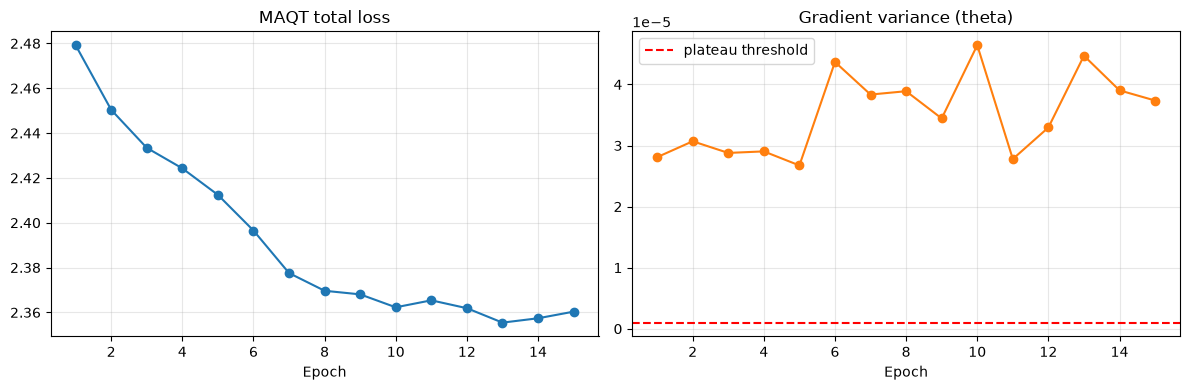

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, epochs + 1), history["loss"], marker="o")
axes[0].set_title("MAQT total loss")
axes[0].set_xlabel("Epoch")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, epochs + 1), history["grad_var"], marker="o", color="tab:orange")
axes[1].axhline(barren_plateau_var, color="red", linestyle="--", label="plateau threshold")
axes[1].set_title("Gradient variance (theta)")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Algo 2: Conformal Zero-Day Threshold Calibration (CQ-ZDR)

Nonconformity score: $s_i = 1 - \max_c F(\rho(x_i), \rho_c)$.

Split-conformal threshold: $q = s_{(k)}$ with $k = \lceil (1 - \alpha)(n + 1) \rceil$.

In [30]:
alpha = 0.05
q, scores_sorted = calibrate_threshold(theta_star, X_cal, prototypes, forward_circuit, alpha=alpha, device=device)
print(f"conformal threshold q = {q:.4f} (alpha={alpha}, n_cal={len(X_cal)})")

conformal threshold q = 0.7478 (alpha=0.05, n_cal=779)


## Algo 3: Unified Inference with Disentangled Rejection

At test time, one pass produces either
- a class label with a certified robustness radius $\rightarrow$ `(label, certified_radius)`, or
- a zero-day flag $\rightarrow$ `(ZERO_DAY, 0)`.

In [31]:
# estimate Lipschitz constant
L_phi = estimate_lipschitz(X_train, theta_star, forward_circuit, n_probe=30, delta=0.05, device=device)
print(f"estimated L_phi = {L_phi:.4f}")

estimated L_phi = 3.5740


## Logging

In [32]:
# write log (final)
log_path = write_history_log(
    history,
    notebook="training-qs-net-pytorch_v2.2.ipynb",
    extra={
        # algo 1: MAQT-based train
        "epochs": epochs,
        "batch_size": batch_size,
        "lr": lr,
        "lambda1": lambda1,
        "lambda2": lambda2,
        "noise_rate": noise_rate,
        "num_layers": num_layers,
        "num_qubits": num_qubits,
        "num_classes": num_classes,
        "n_train": len(X_train),
        "barren_plateau_var": barren_plateau_var,

        # algo 2: conformal
        "alpha": alpha,
        "q": float(q),
        "n_cal": len(X_cal),
        "cal_score_min": float(scores_sorted.min()),
        "cal_score_max": float(scores_sorted.max()),
        "cal_score_mean": float(scores_sorted.mean()),
        
        # algo 3: certified radius
        "L_phi": float(L_phi),
        "Cf": float(DEFAULT_CF) if "DEFAULT_CF" in dir() else float(Cf),
    },
    log_dir="logs",
)
print(f"wrote {log_path.resolve()}")

wrote /home/lawun330/Desktop/qsentinel/quantum-sentinel/logs/training-qs-net-pytorch_v2.2.log


## Evaluation on Known Test Samples

known-sample accuracy (non-rejected): 0.112
rejection rate on test: 0.034
mean certified radius (accepted): 0.0009

classification report (accepted predictions only):
              precision    recall  f1-score   support

    backdoor       0.00      0.00      0.00         5
        ddos       0.08      0.01      0.02        91
         dos       0.00      0.00      0.00        47
   injection       0.50      0.02      0.04       161
        mitm       0.01      0.50      0.02         6
      normal       0.26      0.26      0.26       197
    password       0.21      0.05      0.08       138
    scanning       0.00      0.00      0.00        33
         xss       0.13      0.24      0.17        80

    accuracy                           0.11       758
   macro avg       0.13      0.12      0.06       758
weighted avg       0.23      0.11      0.11       758



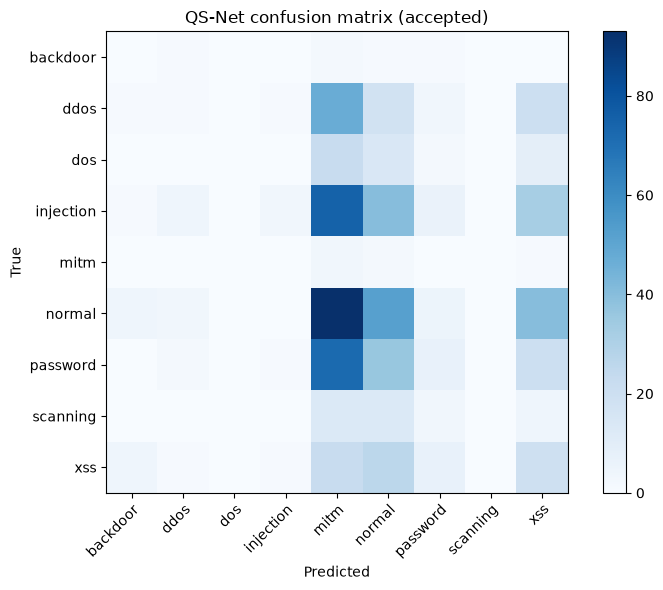

In [33]:
y_pred, radii, novelty_scores = predict_batch(
    X_test, theta_star, prototypes, q, forward_circuit, p=noise_rate, L_phi=L_phi, Cf=DEFAULT_CF, device=device,
)

known_mask = y_pred != ZERO_DAY
label_ids = list(range(num_classes))

known_acc = np.mean(y_pred[known_mask] == y_test[known_mask]) if known_mask.any() else 0.0
reject_rate = 1.0 - known_mask.mean()

print(f"known-sample accuracy (non-rejected): {known_acc:.3f}")
print(f"rejection rate on test: {reject_rate:.3f}")
print(f"mean certified radius (accepted): {radii[known_mask].mean():.4f}")

if known_mask.any():
    print("\nclassification report (accepted predictions only):")
    print(classification_report(
        y_test[known_mask], y_pred[known_mask],
        labels=label_ids, target_names=class_names, zero_division=0,
    ))

    cm = confusion_matrix(y_test[known_mask], y_pred[known_mask], labels=label_ids)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted",
        ylabel="True",
        title="QS-Net confusion matrix (accepted)",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    plt.tight_layout()
    plt.show()

In [34]:
# known-class accuracy using the trained CE readout, not fidelity inference or conformal rejection
with torch.no_grad():
    preds_ce = []
    for x in X_test:
        z, _ = forward_circuit(to_torch_x(x), theta_star)
        z = z if torch.is_tensor(z) else torch.stack(z)
        pred = classifier_head(z.float()).argmax().item()
        preds_ce.append(pred)

print("CE-head accuracy:", np.mean(np.array(preds_ce) == y_test))
print(classification_report(y_test, np.array(preds_ce), labels=label_ids, target_names=class_names, zero_division=0))

CE-head accuracy: 0.09044585987261146
              precision    recall  f1-score   support

    backdoor       0.01      0.40      0.03         5
        ddos       0.09      0.09      0.09        93
         dos       0.12      0.17      0.14        48
   injection       0.35      0.04      0.07       167
        mitm       0.00      0.00      0.00         6
      normal       0.00      0.00      0.00       206
    password       0.15      0.15      0.15       142
    scanning       0.03      0.11      0.05        35
         xss       0.11      0.25      0.15        83

    accuracy                           0.09       785
   macro avg       0.10      0.13      0.07       785
weighted avg       0.13      0.09      0.08       785



## Zero-Day Evaluation

In [35]:
df_zero = pd.read_parquet("data/TON_IoT/quantum/q8_zeroday.parquet")
df_zero

,dst_pkts,protocol,src_pkts,dst_bytes,n_bytes_total,src_bytes,conn_state,duration,label_multiclass,label_binary,label_family
0,0.204968,3.141593,0.0,0.0,0.0,0.0,0.326077,0.0,NaN,NaN,NaN


In [36]:
feature_cols = [c for c in df_zero.columns if not c.startswith("label")]

X_zero = df_zero[feature_cols].values.astype(np.float32)
y_zero = df_zero["label_family"].values

In [37]:
y_zero_pred, radii_zero, scores_zero = predict_batch(X_zero, theta_star, prototypes, q, forward_circuit,
                                                    p=DEFAULT_NOISE_RATE,
                                                    L_phi=L_phi,
                                                    Cf=DEFAULT_CF,
                                                    zero_day=ZERO_DAY,
                                                    device=device)

detected = y_zero_pred == ZERO_DAY
detection_rate = (detected).mean()

print(f"detected as ZERO_DAY: {detected.sum()} / {len(X_zero)} ({detection_rate:.1%})")
print(f"incorrectly accepted: {(~detected).sum()}")
print(f"mean novelty score: {scores_zero.mean():.4f} | threshold q: {q:.4f}")

if (~detected).any():
    for i in np.where(~detected)[0]:
        print(f"  accepted idx={i} true={y_zero[i]} pred={class_names[y_zero_pred[i]]} score={scores_zero[i]:.4f}")

detected as ZERO_DAY: 0 / 1 (0.0%)
incorrectly accepted: 1
mean novelty score: 0.5462 | threshold q: 0.7478
  accepted idx=0 true=nan pred=normal score=0.5462


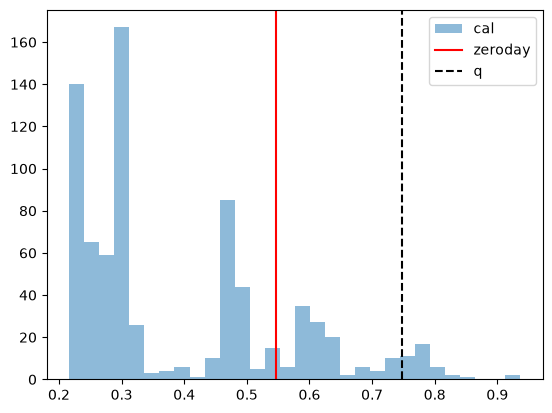

In [38]:
plt.hist(scores_sorted, bins=30, alpha=0.5, label="cal")
plt.axvline(scores_zero[0], color="r", label="zeroday")
plt.axvline(q, color="k", linestyle="--", label="q")
plt.legend(); plt.show()

## References

- Importing PennyLane as qp: https://pennylane.ai/blog/2026/03/import-pennylane-as-qp-growing-beyond-just-qml
- Encoding data in angles: https://docs.pennylane.ai/en/stable/code/api/pennylane.AngleEmbedding.html
- Data reuploading: https://pennylane.ai/demos/tutorial_data_reuploading_classifier
- Strong entangling layers: https://docs.pennylane.ai/en/stable/code/api/pennylane.StronglyEntanglingLayers.html
- Standard depolarization: https://profmcruz.wordpress.com/wp-content/uploads/2017/08/quantum-computation-and-quantum-information-nielsen-chuang.pdf, p-378.
- Standard depolarization in PennyLane: https://docs.pennylane.ai/en/stable/code/api/pennylane.DepolarizingChannel.html